In [1]:
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pathlib import Path

from ddw.utils.mrctools import load_mrc_data

C:\Users\chris\anaconda3\envs\ddw_env\lib\site-packages\lightning_utilities\core\imports.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
print(os.getcwd())

results_dir = Path("../../results/angle_sweep")
angles = [30, 50, 70]

refined_paths = {
    angle: results_dir / f"tomo_even_frames+tomo_odd_frames_mw{angle}_avg_refined.rec"
    for angle in angles
}

for angle, path in refined_paths.items():
    print(angle, path.exists(), path)

C:\Users\chris\Desktop\Fabio\semester-project-deepdewedge\notebooks\subexp03
30 True ..\..\results\angle_sweep\tomo_even_frames+tomo_odd_frames_mw30_avg_refined.rec
50 True ..\..\results\angle_sweep\tomo_even_frames+tomo_odd_frames_mw50_avg_refined.rec
70 True ..\..\results\angle_sweep\tomo_even_frames+tomo_odd_frames_mw70_avg_refined.rec


In [3]:
def load_volume(path):
    vol = load_mrc_data(path)
    if isinstance(vol, torch.Tensor):
        vol = vol.cpu().numpy()
    return vol.astype(np.float32)

refined_avg = {}

for angle, path in refined_paths.items():
    refined_avg[angle] = load_volume(path)

Shared Fourier vmax: 3.7555017471313477


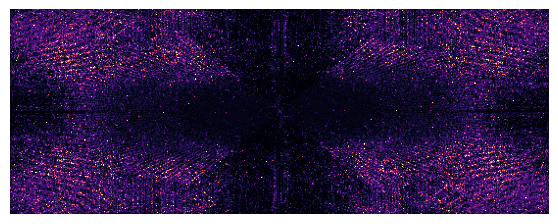

Saved: ..\..\figures\subexp01\fourier_panels\subexp01_fourier_abs_logpower_XZ_30_vs_50.png
Saved: ..\..\figures\subexp01\fourier_panels\subexp01_fourier_abs_logpower_XZ_30_vs_50.pdf


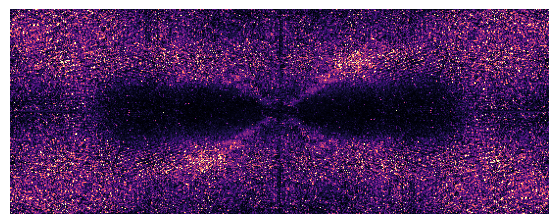

Saved: ..\..\figures\subexp01\fourier_panels\subexp01_fourier_abs_logpower_XZ_70_vs_50.png
Saved: ..\..\figures\subexp01\fourier_panels\subexp01_fourier_abs_logpower_XZ_70_vs_50.pdf


In [4]:
baseline_angle = 50
compare_angles = [30, 70]

baseline_vol = refined_avg[baseline_angle]

out_dir = Path("../../figures/subexp01/fourier_panels")
out_dir.mkdir(parents=True, exist_ok=True)

fourier_cmap = "magma"


# ------------------------------------------------------------
# Helper: memory-efficient central XZ Fourier log-power slice
# ------------------------------------------------------------

def compute_log_power_xz_slice_memory_efficient(vol, eps=1e-8):
    """
    Compute central XZ Fourier log-power slice without creating full 3D FFT volume.

    For volume shape (z, y, x), the ky=0 slice of the 3D FFT is equivalent
    to the 2D FFT of the projection summed over y.
    """
    vol = np.asarray(vol, dtype=np.float32)

    # remove DC bias
    vol = vol - np.mean(vol, dtype=np.float32)

    # ky=0 Fourier slice via projection over y
    proj_xz = np.sum(vol, axis=1, dtype=np.float32)  # shape: (z, x)

    F_xz = np.fft.fftshift(np.fft.fft2(proj_xz))
    log_power_xz = np.log1p(np.abs(F_xz) ** 2 + eps).astype(np.float32)

    return log_power_xz


def add_xz_axis_icon(ax, x0=0.005, y0=0.03, dx=0.13, dy=0.22):
    """
    x to the right, z upwards, paper-style.
    """
    ax.annotate(
        "", xy=(x0 + dx, y0), xytext=(x0, y0),
        xycoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=2.2, color="green")
    )
    ax.annotate(
        "", xy=(x0, y0 + dy), xytext=(x0, y0),
        xycoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=2.2, color="green")
    )

    ax.text(
        x0 + dx / 2, y0 - 0.02, "x",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=16, color="green"
    )

    ax.text(
        x0 - 0.02, y0 + dy / 2, "z",
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=16, color="green"
    )


def add_wedge_contours(ax):
    """
    Optional wedge boundaries, if mask_vols and colors exist.
    """
    if "mask_vols" not in globals():
        return

    for mw in [30, 50, 70]:
        mask_xz = get_xz_slice(mask_vols[mw], y_idx=mask_vols[mw].shape[1] // 2)

        contour_color = colors[mw] if "colors" in globals() else "white"

        ax.contour(
            mask_xz,
            levels=[0.5],
            colors=contour_color,
            linewidths=1.0,
            alpha=0.9
        )


# ------------------------------------------------------------
# Step 1: compute Fourier XZ slices
# ------------------------------------------------------------

baseline_logP_xz = compute_log_power_xz_slice_memory_efficient(baseline_vol)

fourier_absdiff_xz = {}
all_fourier_vals = []

for angle in compare_angles:
    cond_logP_xz = compute_log_power_xz_slice_memory_efficient(refined_avg[angle])

    diff_abs = np.abs(cond_logP_xz - baseline_logP_xz).astype(np.float32)

    fourier_absdiff_xz[angle] = diff_abs
    all_fourier_vals.append(diff_abs.ravel())

all_fourier_vals = np.concatenate(all_fourier_vals)

fourier_vmin = 0.0
fourier_vmax = np.percentile(all_fourier_vals, 99)

print("Shared Fourier vmax:", fourier_vmax)


# Save scale info for final assembly figure
with open(out_dir / "fourier_color_scale.txt", "w") as f:
    f.write(f"fourier_vmin = {fourier_vmin}\n")
    f.write(f"fourier_vmax = {fourier_vmax}\n")
    f.write("quantity = absolute XZ log-power difference\n")


# ------------------------------------------------------------
# Step 2: save clean Fourier panels individually
# ------------------------------------------------------------

for angle in compare_angles:
    img = fourier_absdiff_xz[angle]

    # Natural aspect ratio
    h, w = img.shape
    target_width = 7.0
    fig_height = target_width * h / w

    fig, ax = plt.subplots(figsize=(target_width, fig_height))

    im = ax.imshow(
        img,
        cmap=fourier_cmap,
        origin="lower",
        vmin=fourier_vmin,
        vmax=fourier_vmax,
        aspect="equal"
    )

    add_wedge_contours(ax)
    #add_xz_axis_icon(ax)

    # optional small label; delete if you want completely clean panels
    #ax.text(
    #    0.02, 0.96,
    #    f"|log power {angle}° - log power 50°|",
    #    transform=ax.transAxes,
    #    ha="left", va="top",
    #    fontsize=11,
    #    color="white",
    #    bbox=dict(facecolor="black", alpha=0.45, edgecolor="none", pad=2)
    #)

    ax.axis("off")

    save_png = out_dir / f"subexp01_fourier_abs_logpower_XZ_{angle}_vs_50.png"
    save_pdf = out_dir / f"subexp01_fourier_abs_logpower_XZ_{angle}_vs_50.pdf"

    plt.savefig(save_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.savefig(save_pdf, bbox_inches="tight", pad_inches=0.02)
    plt.show()

    print("Saved:", save_png)
    print("Saved:", save_pdf)

### Subexp02

Different training mw_angles used.

In [5]:
results_dir_02 = Path("../../experiments/subexp02")
angles_train = [40, 50, 60]

refined_paths_02 = {
    angle: results_dir_02 / f"refine_mw{angle}/tomo_even_frames+tomo_odd_frames_train{angle}_mw50_avg_refined.rec"
    for angle in angles_train
}

for angle, path in refined_paths_02.items():
    print(angle, path.exists(), path)
    

refined_avg_02 = {}

for angle, path in refined_paths_02.items():
    refined_avg_02[angle] = load_volume(path)

40 True ..\..\experiments\subexp02\refine_mw40\tomo_even_frames+tomo_odd_frames_train40_mw50_avg_refined.rec
50 True ..\..\experiments\subexp02\refine_mw50\tomo_even_frames+tomo_odd_frames_train50_mw50_avg_refined.rec
60 True ..\..\experiments\subexp02\refine_mw60\tomo_even_frames+tomo_odd_frames_train60_mw50_avg_refined.rec


Shared Fourier vmax: 4.689112663269043


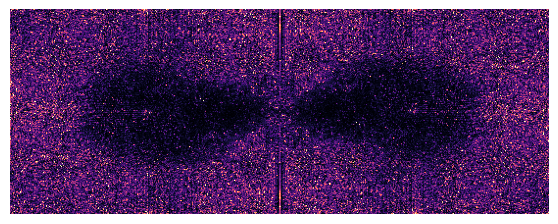

Saved: ..\..\figures\subexp02\fourier_panels\subexp02_fourier_abs_logpower_XZ_40_vs_50.png
Saved: ..\..\figures\subexp02\fourier_panels\subexp02_fourier_abs_logpower_XZ_40_vs_50.pdf


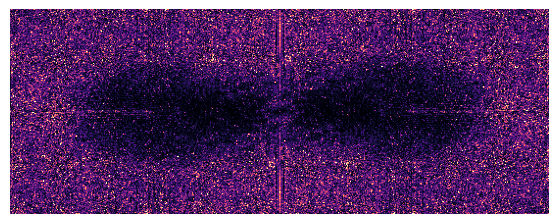

Saved: ..\..\figures\subexp02\fourier_panels\subexp02_fourier_abs_logpower_XZ_60_vs_50.png
Saved: ..\..\figures\subexp02\fourier_panels\subexp02_fourier_abs_logpower_XZ_60_vs_50.pdf


In [6]:
baseline_angle = 50
compare_angles = [40, 60]

baseline_vol = refined_avg_02[baseline_angle]

out_dir = Path("../../figures/subexp02/fourier_panels")
out_dir.mkdir(parents=True, exist_ok=True)

fourier_cmap = "magma"


# ------------------------------------------------------------
# Helper: memory-efficient central XZ Fourier log-power slice
# ------------------------------------------------------------

def compute_log_power_xz_slice_memory_efficient(vol, eps=1e-8):
    """
    Compute central XZ Fourier log-power slice without creating full 3D FFT volume.

    For volume shape (z, y, x), the ky=0 slice of the 3D FFT is equivalent
    to the 2D FFT of the projection summed over y.
    """
    vol = np.asarray(vol, dtype=np.float32)

    # remove DC bias
    vol = vol - np.mean(vol, dtype=np.float32)

    # ky=0 Fourier slice via projection over y
    proj_xz = np.sum(vol, axis=1, dtype=np.float32)  # shape: (z, x)

    F_xz = np.fft.fftshift(np.fft.fft2(proj_xz))
    log_power_xz = np.log1p(np.abs(F_xz) ** 2 + eps).astype(np.float32)

    return log_power_xz


def add_xz_axis_icon(ax, x0=0.005, y0=0.03, dx=0.13, dy=0.22):
    """
    x to the right, z upwards, paper-style.
    """
    ax.annotate(
        "", xy=(x0 + dx, y0), xytext=(x0, y0),
        xycoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=2.2, color="green")
    )
    ax.annotate(
        "", xy=(x0, y0 + dy), xytext=(x0, y0),
        xycoords="axes fraction",
        arrowprops=dict(arrowstyle="->", lw=2.2, color="green")
    )

    ax.text(
        x0 + dx / 2, y0 - 0.02, "x",
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=16, color="green"
    )

    ax.text(
        x0 - 0.02, y0 + dy / 2, "z",
        transform=ax.transAxes,
        ha="center", va="center",
        fontsize=16, color="green"
    )


def add_wedge_contours(ax):
    """
    Optional wedge boundaries, if mask_vols and colors exist.
    """
    if "mask_vols" not in globals():
        return

    for mw in [30, 50, 70]:
        mask_xz = get_xz_slice(mask_vols[mw], y_idx=mask_vols[mw].shape[1] // 2)

        contour_color = colors[mw] if "colors" in globals() else "white"

        ax.contour(
            mask_xz,
            levels=[0.5],
            colors=contour_color,
            linewidths=1.0,
            alpha=0.9
        )


# ------------------------------------------------------------
# Step 1: compute Fourier XZ slices
# ------------------------------------------------------------

baseline_logP_xz = compute_log_power_xz_slice_memory_efficient(baseline_vol)

fourier_absdiff_xz = {}
all_fourier_vals = []

for angle in compare_angles:
    cond_logP_xz = compute_log_power_xz_slice_memory_efficient(refined_avg_02[angle])

    diff_abs = np.abs(cond_logP_xz - baseline_logP_xz).astype(np.float32)

    fourier_absdiff_xz[angle] = diff_abs
    all_fourier_vals.append(diff_abs.ravel())

all_fourier_vals = np.concatenate(all_fourier_vals)

fourier_vmin = 0.0
fourier_vmax = np.percentile(all_fourier_vals, 99)

print("Shared Fourier vmax:", fourier_vmax)


# Save scale info for final assembly figure
with open(out_dir / "fourier_color_scale.txt", "w") as f:
    f.write(f"fourier_vmin = {fourier_vmin}\n")
    f.write(f"fourier_vmax = {fourier_vmax}\n")
    f.write("quantity = absolute XZ log-power difference\n")


# ------------------------------------------------------------
# Step 2: save clean Fourier panels individually
# ------------------------------------------------------------

for angle in compare_angles:
    img = fourier_absdiff_xz[angle]

    # Natural aspect ratio
    h, w = img.shape
    target_width = 7.0
    fig_height = target_width * h / w

    fig, ax = plt.subplots(figsize=(target_width, fig_height))

    im = ax.imshow(
        img,
        cmap=fourier_cmap,
        origin="lower",
        vmin=fourier_vmin,
        vmax=fourier_vmax,
        aspect="equal"
    )

    add_wedge_contours(ax)
    #add_xz_axis_icon(ax)

    # optional small label; delete if you want completely clean panels
    #ax.text(
    #    0.02, 0.96,
    #    f"|log power {angle}° - log power 50°|",
    #    transform=ax.transAxes,
    #    ha="left", va="top",
    #    fontsize=11,
    #    color="white",
    #    bbox=dict(facecolor="black", alpha=0.45, edgecolor="none", pad=2)
    #)

    ax.axis("off")

    save_png = out_dir / f"subexp02_fourier_abs_logpower_XZ_{angle}_vs_50.png"
    save_pdf = out_dir / f"subexp02_fourier_abs_logpower_XZ_{angle}_vs_50.pdf"

    plt.savefig(save_png, dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.savefig(save_pdf, bbox_inches="tight", pad_inches=0.02)
    plt.show()

    print("Saved:", save_png)
    print("Saved:", save_pdf)